# ST-FFT Demo

This notebook demonstrates the **Spatial-Temporal Fast Fourier Transform (ST-FFT)**
pipeline for thermal-video data-quality improvement and geometry recovery.

It runs on a **synthetic thermal video** so it works without the private
dataset. To use your own data, replace the synthetic block with
`stfft.io.load_png_sequence(...)` or `stfft.io.load_csv_sequence(...)`.

Pipeline stages:
1. **IQA** - SNR-based frame filtering
2. **Drift correction** - FFT phase cross-correlation
3. **ST-FFT** - FFT-S (spatial low-pass) + FFT-T (temporal peak)
4. **Geometry recovery** - direct ellipse fitting

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../src"))

import numpy as np
import matplotlib.pyplot as plt
import stfft

## 1. Build a synthetic thermal video

A bright elliptical "molten zone" on a cool background, with small inter-frame drift and additive sensor noise. Some frames are deliberately degraded (low SNR).

video shape: (120, 160, 60)


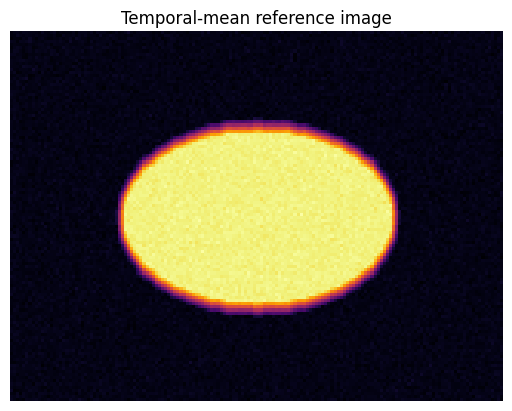

In [2]:
np.random.seed(0)
H, W, T = 120, 160, 60
yy, xx = np.mgrid[0:H, 0:W]
video = np.zeros((H, W, T))

for t in range(T):
    cy, cx = H/2 + (t % 5 - 2), W/2 + (t % 3 - 1)      # small drift
    ellipse = (((xx - cx) / 45) ** 2 + ((yy - cy) / 30) ** 2) <= 1
    frame = np.where(ellipse, 210.0, 60.0)
    noise = 30 if t % 6 == 0 else 8                      # some bad frames
    frame += np.random.normal(0, noise, (H, W))
    video[:, :, t] = np.clip(frame, 0, 255)

print("video shape:", video.shape)
plt.imshow(np.mean(video, axis=2), cmap="inferno")
plt.title("Temporal-mean reference image"); plt.axis("off"); plt.show()

## 2. Image Quality Assessment (IQA)

Segment the object on the reference image, then score every frame's SNR and keep only frames above the reference SNR.

reference SNR = 11.238
kept 33 / 60 frames


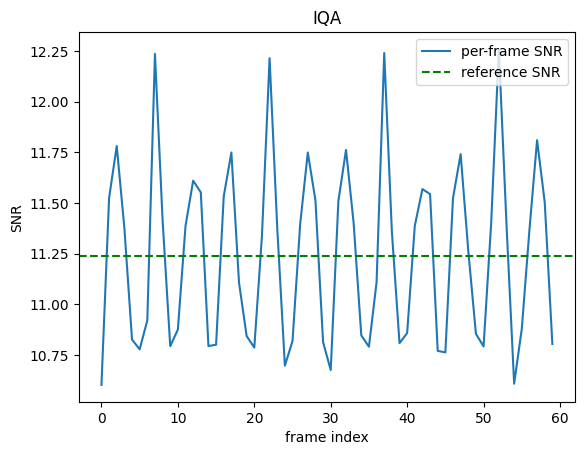

In [3]:
reference = np.mean(video, axis=2)
object_map = stfft.segmentation.kmeans_threshold(reference, k=2)
binary, signal, noise = stfft.segmentation.object_pixels(object_map)

ref_snr = stfft.iqa.snr(reference, signal, noise)
scores = stfft.iqa.assess_video(video, signal, noise)
filtered, kept = stfft.iqa.select_frames(video, scores, ref_snr)

print(f"reference SNR = {ref_snr:.3f}")
print(f"kept {len(kept)} / {T} frames")

plt.plot(scores, label="per-frame SNR")
plt.axhline(ref_snr, color="g", ls="--", label="reference SNR")
plt.xlabel("frame index"); plt.ylabel("SNR"); plt.legend(); plt.title("IQA"); plt.show()

## 3. Drift correction

Register each kept frame to the temporal mean via FFT phase cross-correlation.

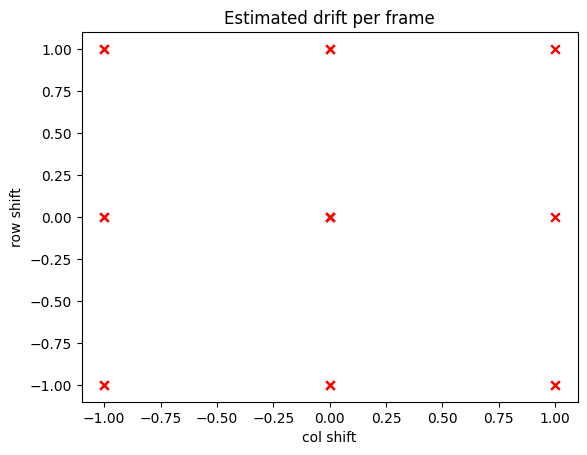

In [4]:
corrected, shifts = stfft.drift.correct_video(filtered)
plt.scatter(shifts[:, 1], shifts[:, 0], marker="x", c="red")
plt.xlabel("col shift"); plt.ylabel("row shift"); plt.title("Estimated drift per frame"); plt.show()

## 4. ST-FFT quality improvement

Apply the spatial Gaussian low-pass (FFT-S) followed by the per-pixel temporal peak (FFT-T).

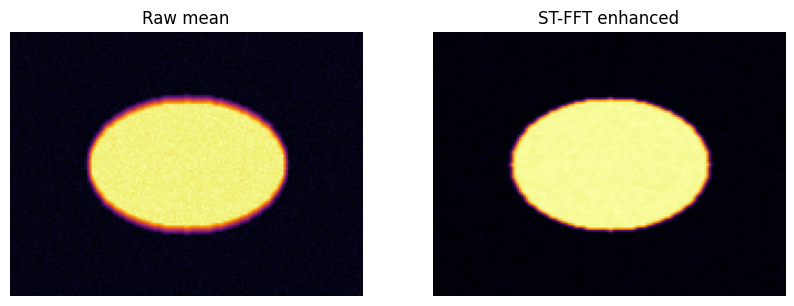

In [5]:
enhanced, spatial = stfft.transform.st_fft(corrected, cutoff=30.0)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(reference, cmap="inferno"); ax[0].set_title("Raw mean"); ax[0].axis("off")
ax[1].imshow(enhanced, cmap="inferno"); ax[1].set_title("ST-FFT enhanced"); ax[1].axis("off")
plt.show()

## 5. Geometry recovery

Segment the enhanced image, extract the boundary contour, and fit an ellipse.

center  : (80.0, 60.0)
semi-axes: ap=44.6, bp=29.4
eccentricity: 0.751


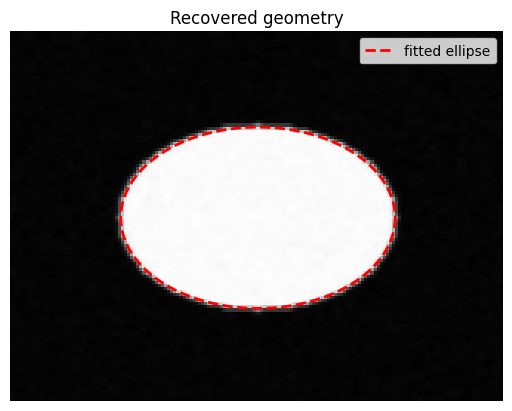

In [6]:
enhanced_norm = stfft.transform.normalize(enhanced)
obj = stfft.segmentation.kmeans_threshold(enhanced_norm, k=2)
binary_enh, _, _ = stfft.segmentation.object_pixels(obj)

geom = stfft.geometry.recover_geometry(binary_enh)
print("center  : (%.1f, %.1f)" % (geom["x0"], geom["y0"]))
print("semi-axes: ap=%.1f, bp=%.1f" % (geom["ap"], geom["bp"]))
print("eccentricity: %.3f" % geom["eccentricity"])

xs, ys = stfft.geometry.get_ellipse_pts(
    (geom["x0"], geom["y0"], geom["ap"], geom["bp"], geom["eccentricity"], geom["phi"]))
plt.imshow(enhanced_norm, cmap="gray")
plt.plot(xs, ys, "r--", lw=2, label="fitted ellipse")
plt.legend(); plt.axis("off"); plt.title("Recovered geometry"); plt.show()

## 6. Side-view surface profile

Build the per-pixel index matrix, sample concentric contours by shrinking the fitted ellipse, and fit the upper-minus-lower surface profile.

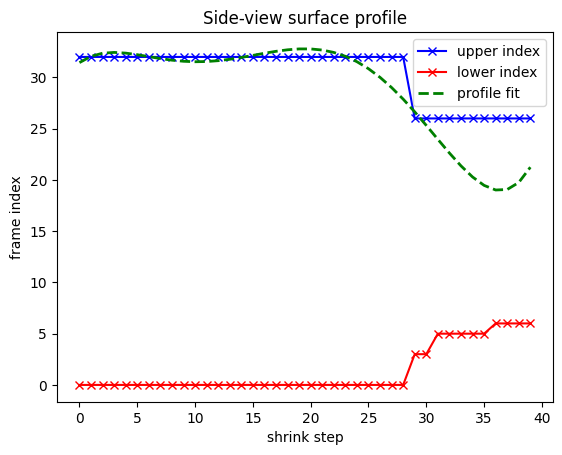

In [7]:
idx = stfft.profile.index_matrix(corrected)
xs, upper, lower = stfft.profile.sample_contours(
    idx, (geom["x0"], geom["y0"]), geom["ap"], geom["bp"], n_steps=40)
prof = stfft.profile.surface_profile(upper, lower)
poly, fitted = stfft.profile.fit_profile(xs, prof, degree=5)

plt.plot(xs, upper, "b-x", label="upper index")
plt.plot(xs, lower, "r-x", label="lower index")
plt.plot(xs, fitted, "g--", lw=2, label="profile fit")
plt.xlabel("shrink step"); plt.ylabel("frame index")
plt.legend(); plt.title("Side-view surface profile"); plt.show()

## 7. One-line end-to-end

Everything above is wrapped in `stfft.run_pipeline`.

In [8]:
out = stfft.run_pipeline(video, k=2, cutoff=30.0, do_drift=True)
g = out["geometry"]
print("kept frames :", len(out["kept_frames"]))
print("ellipse ap/bp:", round(g["ap"], 1), "/", round(g["bp"], 1))
print("eccentricity:", round(g["eccentricity"], 3))

kept frames : 33
ellipse ap/bp: 43.8 / 29.3
eccentricity: 0.745
